In [1]:
!pip install pandas


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
df = pd.read_csv('city_day.csv')

In [3]:
df.shape
df.info()
df.describe()
df['City'].nunique()
df['AQI_Bucket'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


array([nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory',
       'Good'], dtype=object)

In [4]:
pip install meteostat geopy requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\python.exe -m pip install --upgrade pip


In [5]:

import pandas as pd
import requests
import time

# Load your dataset
df = pd.read_csv('city_day.csv')
df['Date'] = pd.to_datetime(df['Date'])

# COMPLETE Dictionary of Coordinates for all cities in your dataset
city_coords = {
    'Ahmedabad': {'lat': 23.0225, 'lon': 72.5714},
    'Aizawl': {'lat': 23.7271, 'lon': 92.7176},
    'Amaravati': {'lat': 16.5131, 'lon': 80.5165},
    'Amritsar': {'lat': 31.6340, 'lon': 74.8723},
    'Bengaluru': {'lat': 12.9716, 'lon': 77.5946},
    'Bhopal': {'lat': 23.2599, 'lon': 77.4126},
    'Brajrajnagar': {'lat': 21.8216, 'lon': 83.9216},
    'Chandigarh': {'lat': 30.7333, 'lon': 76.7794},
    'Chennai': {'lat': 13.0827, 'lon': 80.2707},
    'Coimbatore': {'lat': 11.0168, 'lon': 76.9558},
    'Delhi': {'lat': 28.6139, 'lon': 77.2090},
    'Ernakulam': {'lat': 9.9816, 'lon': 76.2999},
    'Gurugram': {'lat': 28.4601, 'lon': 77.0199},
    'Guwahati': {'lat': 26.1445, 'lon': 91.7362},
    'Hyderabad': {'lat': 17.3850, 'lon': 78.4867},
    'Jaipur': {'lat': 26.9124, 'lon': 75.7873},
    'Jorapokhar': {'lat': 23.7004, 'lon': 86.4125},
    'Kochi': {'lat': 9.9312, 'lon': 76.2673},
    'Kolkata': {'lat': 22.5726, 'lon': 88.3639},
    'Lucknow': {'lat': 26.8467, 'lon': 80.9462},
    'Mumbai': {'lat': 19.0760, 'lon': 72.8777},
    'Patna': {'lat': 25.5941, 'lon': 85.1376},
    'Shillong': {'lat': 25.5788, 'lon': 91.8933},
    'Talcher': {'lat': 20.9509, 'lon': 85.2163},
    'Thiruvananthapuram': {'lat': 8.5241, 'lon': 76.9366},
    'Visakhapatnam': {'lat': 17.6868, 'lon': 83.2185}
}

weather_frames = []

# Fetch data using the complete list
for city in df['City'].unique():
    # Safety check in case a new city appears in future data
    if city not in city_coords:
        print(f"⚠️ Skipping {city}: Coordinates still missing.")
        continue
        
    lat = city_coords[city]['lat']
    lon = city_coords[city]['lon']
    
    # Get date range for this specific city
    city_data = df[df['City'] == city]
    start_date = city_data['Date'].min().strftime('%Y-%m-%d')
    end_date = city_data['Date'].max().strftime('%Y-%m-%d')
    
    print(f"Fetching data for {city}...")
    
    try:
        # Fetch Temperature, Humidity, and Wind Speed
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=auto"
        
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            
            # Create a temporary dataframe for the weather data
            temp_df = pd.DataFrame({
                'Date': pd.to_datetime(data['daily']['time']),
                'City': city,
                'Temp_Mean': data['daily']['temperature_2m_mean'],
                'Humidity_Mean': data['daily']['relative_humidity_2m_mean'],
                'Wind_Speed_Max': data['daily']['wind_speed_10m_max']
            })
            weather_frames.append(temp_df)
        else:
            print(f"❌ Error fetching {city}: {response.status_code}")
            
    except Exception as e:
        print(f"❌ Exception for {city}: {e}")
    
    # Pause briefly to respect API rate limits
    time.sleep(1)

# Combine and Merge
if weather_frames:
    all_weather_df = pd.concat(weather_frames)
    
    # Merge with original data
    final_df = pd.merge(df, all_weather_df, on=['City', 'Date'], how='left')
    
    # Save to CSV
    final_df.to_csv('city_day_with_weather_complete.csv', index=False)
    print("\n✅ Success! All cities updated. Saved to 'city_day_with_weather_complete.csv'")
else:
    print("\n❌ No weather data fetched.")

Fetching data for Ahmedabad...
Fetching data for Aizawl...
Fetching data for Amaravati...
Fetching data for Amritsar...
Fetching data for Bengaluru...
Fetching data for Bhopal...
Fetching data for Brajrajnagar...
Fetching data for Chandigarh...
Fetching data for Chennai...
Fetching data for Coimbatore...
Fetching data for Delhi...
Fetching data for Ernakulam...
Fetching data for Gurugram...
Fetching data for Guwahati...
Fetching data for Hyderabad...
Fetching data for Jaipur...
Fetching data for Jorapokhar...
Fetching data for Kochi...
Fetching data for Kolkata...
Fetching data for Lucknow...
Fetching data for Mumbai...
Fetching data for Patna...
Fetching data for Shillong...
Fetching data for Talcher...
Fetching data for Thiruvananthapuram...
Fetching data for Visakhapatnam...

✅ Success! All cities updated. Saved to 'city_day_with_weather_complete.csv'


In [6]:
import numpy as np
df = pd.read_csv('city_day_with_weather_complete.csv')
df_numeric = df.select_dtypes(include=np.number)

df_numeric.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,20.3,67,14.8
1,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,20.4,65,15.6
2,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,19.7,70,11.4
3,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,19.8,64,13.6
4,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,19.0,53,15.2


In [7]:
df_numeric = df.select_dtypes(include=np.number)

df_numeric.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,20.3,67,14.8
1,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,20.4,65,15.6
2,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,19.7,70,11.4
3,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,19.8,64,13.6
4,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,19.0,53,15.2


In [8]:
corr_matrix = df_numeric.corr()
corr_matrix['AQI'].sort_values(ascending=False)
corr_target = corr_matrix['AQI'].abs()

selected_features = corr_target[corr_target > 0.3].index
selected_features

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI'], dtype='object')

In [9]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


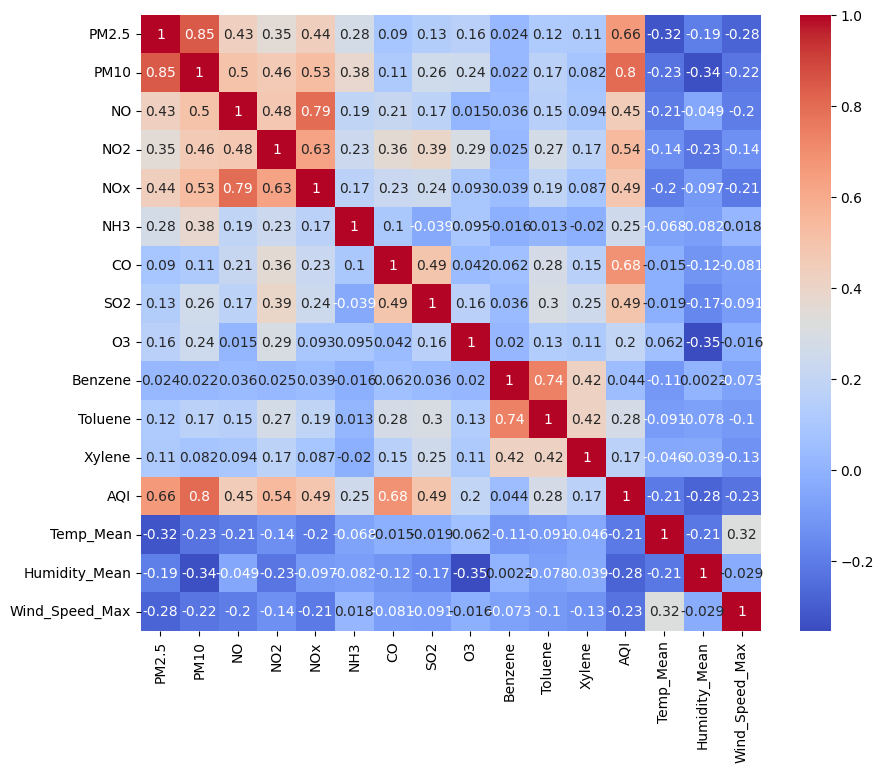

In [10]:
X = df_numeric[selected_features]
y = df_numeric['AQI']
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.show()

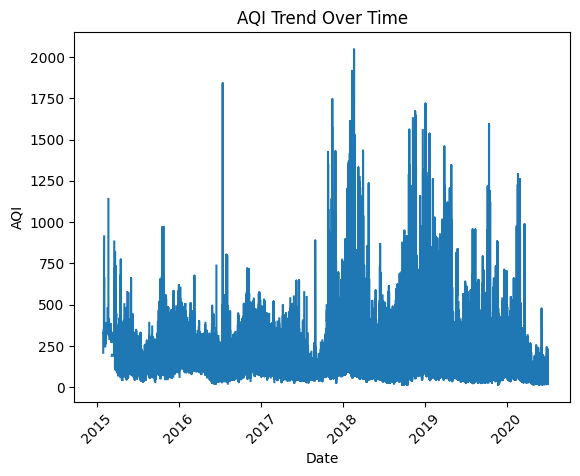

In [11]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date (very important for time series)
df = df.sort_values('Date')
plt.figure()
plt.plot(df['Date'], df['AQI'])
plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

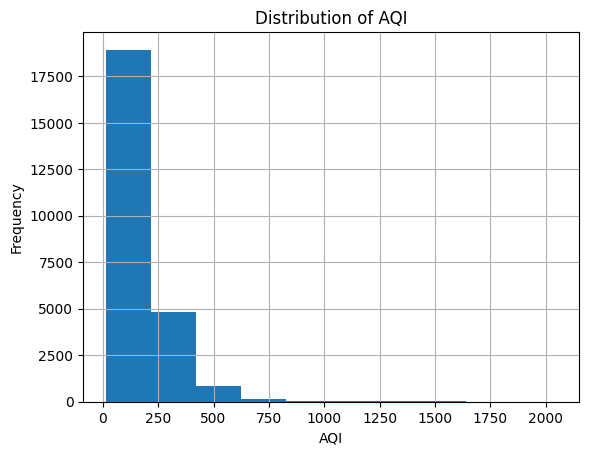

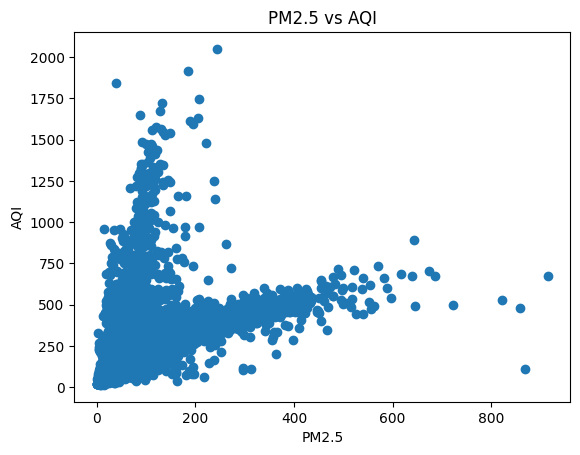

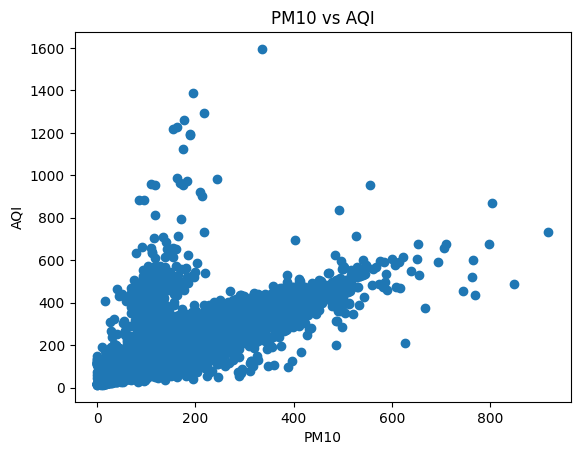

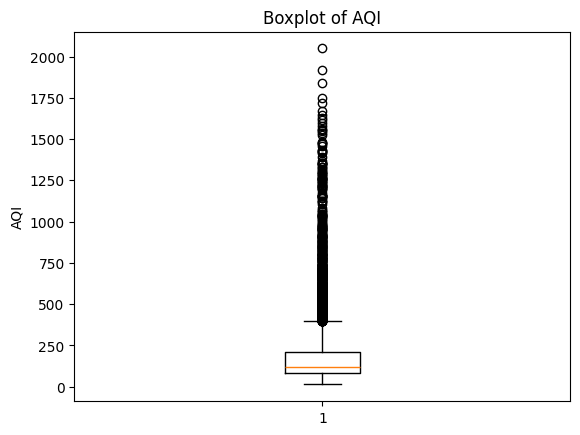

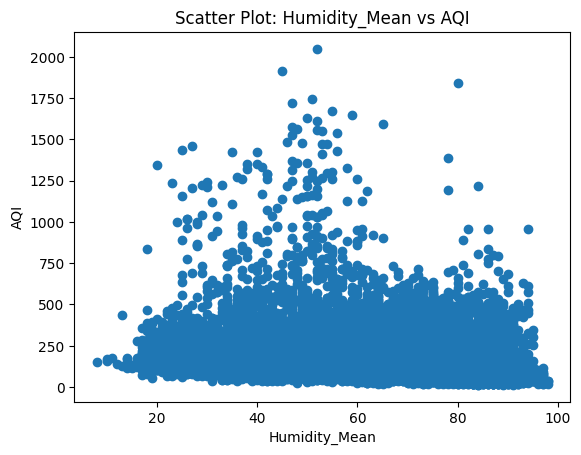

<Figure size 640x480 with 0 Axes>

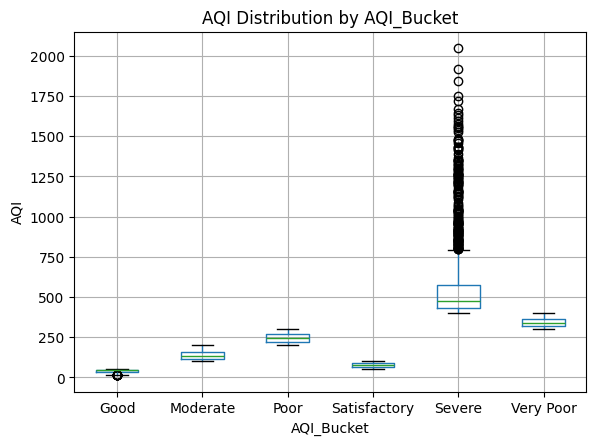

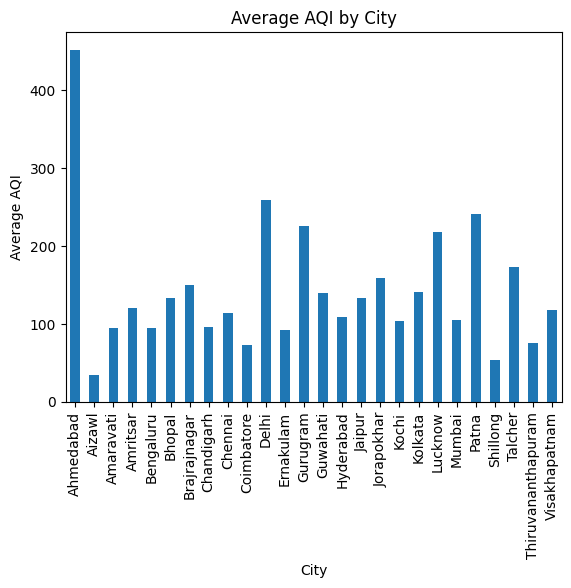

In [12]:
# 1. Histogram - AQI
plt.figure()
df['AQI'].dropna().hist()
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


# 2. Scatter Plot - PM2.5 vs AQI
plt.figure()
plt.scatter(df['PM2.5'], df['AQI'])
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()


# 3. Scatter Plot - PM10 vs AQI
plt.figure()
plt.scatter(df['PM10'], df['AQI'])
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()


# 4. Boxplot - AQI (Outlier Detection)
plt.figure()
plt.boxplot(df['AQI'].dropna())
plt.title("Boxplot of AQI")
plt.ylabel("AQI")
plt.show()

plt.figure()
plt.scatter(df['Humidity_Mean'], df['AQI'])
plt.title("Scatter Plot: Humidity_Mean vs AQI")
plt.xlabel("Humidity_Mean")
plt.ylabel("AQI")
plt.show()

plt.figure()
df.boxplot(column='AQI', by='AQI_Bucket')
plt.title("AQI Distribution by AQI_Bucket")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("AQI_Bucket")
plt.ylabel("AQI")
plt.show()


# Bar Plot: Average AQI by City
# ----------------------------
plt.figure()
df.groupby('City')['AQI'].mean().plot(kind='bar')
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()

In [13]:
df = pd.read_csv('city_day_with_weather_complete.csv')

df = df.dropna(subset=['AQI', 'AQI_Bucket'])

columns_to_drop = [
    'AQI_Bucket',
    'NO',
    'NOx',
    'NH3',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]

df = df.drop(columns=columns_to_drop)

In [14]:
# 1. Remove all rows where City is 'Lucknow'
df = df[df['City'] != 'Lucknow']
df.isnull().sum()

City                 0
Date                 0
PM2.5              676
PM10              5193
NO2                389
CO                 437
SO2                604
AQI                  0
Temp_Mean            0
Humidity_Mean        0
Wind_Speed_Max       0
dtype: int64

In [15]:
df.to_csv('city_day_clean.csv', index=False)

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Load the dataset (after dropping NaN targets)
df = pd.read_csv('city_day_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Define a STRICT, safe interpolation function
def safe_interpolate(group):
    numeric_cols = group.select_dtypes(include=['number']).columns
    
    # limit=7: Only draw a line if the gap is 7 days or less
    # limit_area='inside': NEVER backfill or forward-fill into the unknown edges
    group[numeric_cols] = group[numeric_cols].interpolate(
        method='linear', 
        limit=7, 
        limit_area='inside'
    )
    return group

# Apply safe interpolation
df_interpolated = df.groupby('City', group_keys=False).apply(safe_interpolate)

# 3. Use Machine Learning to fill the remaining large gaps (Multivariate Imputation)
# This will use the correlations between PM2.5, NO2, Temp, etc., to guess missing PM10
print(f"Missing before Iterative Imputer: \n{df_interpolated.isnull().sum()}")

# Isolate numeric columns for the imputer
numeric_df = df_interpolated.select_dtypes(include=['number'])
numeric_cols = numeric_df.columns

# Initialize Iterative Imputer (using a fast estimator like Ridge or small Random Forest)
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42
)

# Fit and transform
print("Running Iterative Imputer (this may take a minute)...")
imputed_data = imputer.fit_transform(numeric_df)

# Put the imputed data back into the dataframe
df_interpolated[numeric_cols] = imputed_data

print(f"Missing after Iterative Imputer: \n{df_interpolated.isnull().sum()}")

# Save
df_interpolated.to_csv('city_day_interpolated_fixed.csv', index=False)

C:\Users\prasi\AppData\Local\Temp\ipykernel_5824\1559792551.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interpolated = df.groupby('City', group_keys=False).apply(safe_interpolate)


Missing before Iterative Imputer: 
City                 0
Date                 0
PM2.5              495
PM10              4958
NO2                168
CO                 259
SO2                298
AQI                  0
Temp_Mean            0
Humidity_Mean        0
Wind_Speed_Max       0
dtype: int64
Running Iterative Imputer (this may take a minute)...
Missing after Iterative Imputer: 
City              0
Date              0
PM2.5             0
PM10              0
NO2               0
CO                0
SO2               0
AQI               0
Temp_Mean         0
Humidity_Mean     0
Wind_Speed_Max    0
dtype: int64


c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [17]:
pip install xgboost lightgbm tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\prasi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages (3.2.0)




[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
df_interpolated.isnull().sum()

City              0
Date              0
PM2.5             0
PM10              0
NO2               0
CO                0
SO2               0
AQI               0
Temp_Mean         0
Humidity_Mean     0
Wind_Speed_Max    0
dtype: int64

In [20]:
y = df_interpolated['AQI']

# Features
X = df_interpolated.drop(columns=['AQI'])

In [21]:
X = X.copy()

X['Date'] = pd.to_datetime(X['Date'], errors='coerce')

X['year'] = X['Date'].dt.year
X['month'] = X['Date'].dt.month
X['day'] = X['Date'].dt.day
X['day_of_week'] = X['Date'].dt.dayofweek

X = X.drop(columns=['Date'])

df_interpolated = df_interpolated.sort_values(by=['City', 'Date'])

split_index = int(0.8 * len(X))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 18365
Testing set size: 4592


In [22]:
categorical_features = ['City']
numeric_features = X.drop(columns=['City']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [23]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [25]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1))
])

In [26]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(n_estimators=100))
])

In [27]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [28]:
# Drop non-numeric columns
lstm_df = df_interpolated.drop(columns=['City', 'Date'])

# Scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(lstm_df)

# Create sequences
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length, :-1])
        y.append(data[i+seq_length, -1])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled_data)

# Split
split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

In [29]:
model_lstm = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32)

Epoch 1/10


c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0061
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0059
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0058
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0058
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0057
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0057
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0057
Epoch 9/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056
Epoch 10/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0056


In [30]:
models = {
    "Ridge Regression": ridge_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

results = []

# 🔹 Sklearn Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, rmse, r2])


# 🔹 LSTM Model (separate handling)

# Predict
y_pred_lstm = model_lstm.predict(X_test_lstm)
y_pred_lstm = y_pred_lstm.flatten()

# If you used scaling → inverse transform
y_pred_lstm = y_pred_lstm.reshape(-1, 1)
y_test_lstm = y_test_lstm.reshape(-1, 1)

y_pred_actual = scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred_lstm), scaled_data.shape[1]-1)), y_pred_lstm), axis=1)
)[:, -1]

y_test_actual = scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test_lstm), scaled_data.shape[1]-1)), y_test_lstm), axis=1)
)[:, -1]

# Metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

results.append(["LSTM", mse, rmse, r2])


# 🔹 Convert to DataFrame (BEST for report)
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])

print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000668 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1941
[LightGBM] [Info] Number of data points in the train set: 18365, number of used features: 32
[LightGBM] [Info] Start training from score 164.630602
  1/144 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step

c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              Model          MSE       RMSE        R2
0  Ridge Regression  1187.696838  34.462978  0.901511
1     Random Forest   732.212209  27.059420  0.939282
2           XGBoost   730.700078  27.031465  0.939407
3          LightGBM   695.523454  26.372779  0.942324
4              LSTM    26.336439   5.131904  0.176729


In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
import numpy as np

# Upgrade the numeric pipeline to include Polynomial Features
numeric_transformer_advanced = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # degree=2 squares the features and multiplies them together. 
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
    ('scaler', StandardScaler())
])

# Update preprocessor with the new numeric transformer
preprocessor_advanced = ColumnTransformer([
    ('num', numeric_transformer_advanced, numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Build the model
ridge_model_advanced = Pipeline([
    ('preprocessor', preprocessor_advanced),
    # Wrap RidgeCV inside a TransformedTargetRegressor to apply the Log Transform
    ('model', TransformedTargetRegressor(
        # RidgeCV will automatically test 100 different alphas from 0.001 to 1000
        regressor=RidgeCV(alphas=np.logspace(-3, 3, 100)), 
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# Train and evaluate
print("Training Advanced Ridge...")
ridge_model_advanced.fit(X_train, y_train)
y_pred_ridge = ridge_model_advanced.predict(X_test)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"Upgraded Ridge - MSE: {ridge_mse:.2f}, RMSE: {ridge_rmse:.2f}, R2: {ridge_r2:.4f}")

Training Advanced Ridge...
Upgraded Ridge - MSE: 1275.94, RMSE: 35.72, R2: 0.8942
